CSVファイルを読み込んでいます: E:\refit\all_map_spectra.csv
データを2Dマップ形式に変換しています...


C:\Users\yudon\AppData\Local\Temp\ipykernel_7628\1789801479.py:38: FutureWarning: The provided callable <function mean at 0x00000146FDAEE020> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  map_data = df.pivot_table(index=y_column, columns=x_column, values=wavelength_column, aggfunc=np.mean)


マップを描画しています...
マップを画像として保存しました: map_1675_39nm.png


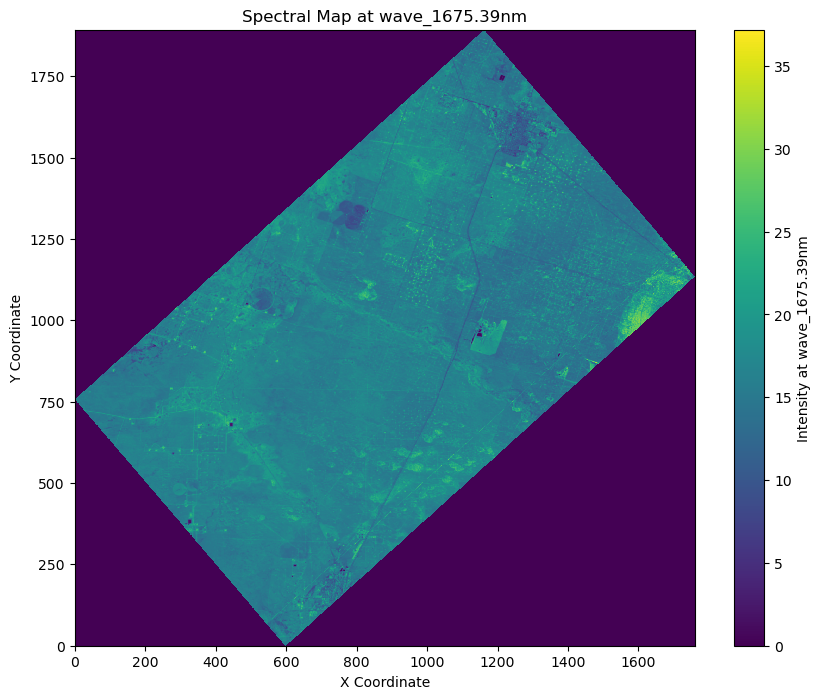

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 設定 (環境に合わせて確認・変更してください) ---

# CSVファイルのパス
file_path = r"E:\refit\all_map_spectra.csv"

# マップを作成したい波長の列名
wavelength_column = 'wave_1675.39nm'

# 座標軸の列名 (CSVファイルのヘッダー名と一致させてください)
# ★★★ もしCSVの列名が 'y', 'x' でない場合は、ここを修正してください ★★★
y_column = 'y'  # Y座標の列名 (仮定)
x_column = 'x'  # X座標の列名 (仮定)

# 保存する画像ファイル名
output_image_file = 'map_1675_39nm.png'

# --- 2. メイン処理 (ここから下は通常変更不要) ---

try:
    # CSVファイルの読み込み
    print(f"CSVファイルを読み込んでいます: {file_path}")
    df = pd.read_csv(file_path)

    # 必要な列が存在するか確認
    required_columns = [y_column, x_column, wavelength_column]
    if not all(col in df.columns for col in required_columns):
        print(f"エラー: 必要な列 {required_columns} のいずれかが見つかりません。")
        print(f"CSVにある実際の列名: {df.columns.tolist()}")
        print("---")
        print(f"★★★ コードセルの上部にある 'y_column' と 'x_column' の設定を、実際の列名（'{df.columns[0]}', '{df.columns[1]}'など）に修正してください。 ★★★")
    else:
        # データを2Dマップ形式に変換 (ピボットテーブル)
        print("データを2Dマップ形式に変換しています...")
        map_data = df.pivot_table(index=y_column, columns=x_column, values=wavelength_column, aggfunc=np.mean)

        # マップの描画
        print("マップを描画しています...")
        plt.figure(figsize=(10, 8))
        
        # imshowで画像表示
        # origin='lower' は (0,0) を左下隅にします。
        # もしY座標が上から下に増加するデータ（画像の標準）の場合は 'upper' に変更してください。
        im = plt.imshow(map_data, aspect='auto', interpolation='none', origin='lower',
                        extent=[map_data.columns.min(), map_data.columns.max(),
                                map_data.index.min(), map_data.index.max()])

        # カラーバーの追加
        plt.colorbar(im, label=f'Intensity at {wavelength_column}')

        # タイトルと軸ラベルの設定
        plt.title(f'Spectral Map at {wavelength_column}')
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')

        # 画像ファイルとして保存
        plt.savefig(output_image_file)
        print(f"マップを画像として保存しました: {output_image_file}")

        # Jupyter Notebookのセル下に画像を表示
        plt.show()

except FileNotFoundError:
    print(f"エラー: ファイルが見つかりません: {file_path}")
except Exception as e:
    print(f"エラーが発生しました: {e}")

In [3]:
import os
current_dir = os.getcwd()
print(f"=========================================================")
print(f"現在の作業フォルダ (ここに 'estimated_ch4_map.png' が保存されます):")
print(f"{current_dir}")
print(f"=========================================================")
    # --- ★ここまで追加 ---


現在の作業フォルダ (ここに 'estimated_ch4_map.png' が保存されます):
c:\Users\yudon\AppData\Local\Programs\Microsoft VS Code


CSVファイルを読み込みました。Shape: (3335334, 187)
'wave_1025.91nm' から 'wave_1238.24nm' までの 18 バンドを抽出しました。
推定される画像サイズ: H=1894, W=1761

ステップ2: データを標準化しています...
ステップ3: PCAを実行しています...
PCAが完了しました。


c:\Users\yudon\anaconda3\envs\hisui\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yudon\anaconda3\envs\hisui\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yudon\anaconda3\envs\hisui\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yudon\anaconda3\envs\hisui\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\yudon\anaconda3\envs\hisui\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK U

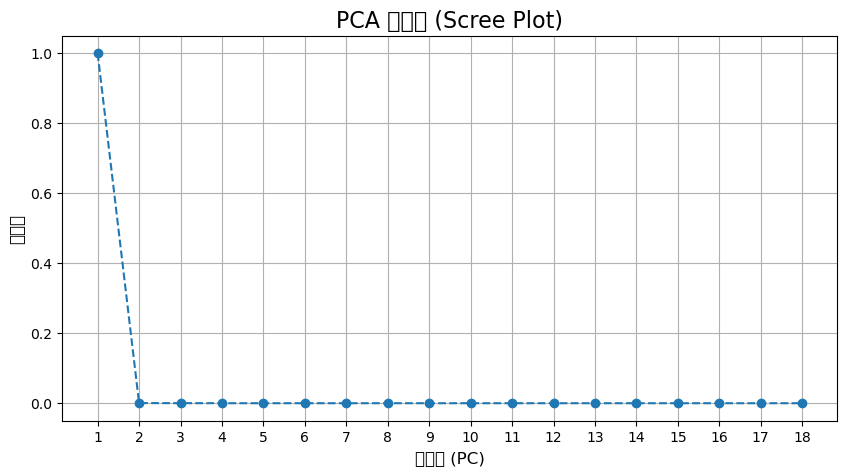

 -> 上位の主成分 (PC1, PC2...) がデータのほとんどを説明し、
 -> 下位の主成分 (PC10, PC11...) の寄与率が低い（＝ノイズやエラー成分）ことを確認してください。

ステップ4: PCAの結果を (H, W, Components) の画像形式に再構成しています...
画像の再構成が完了しました。

ステップ5: 全ての主成分画像をプロットします...


C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\1062762314.py:127: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\1062762314.py:127: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\1062762314.py:127: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\1062762314.py:127: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.98])
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\1062762314.py:127: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

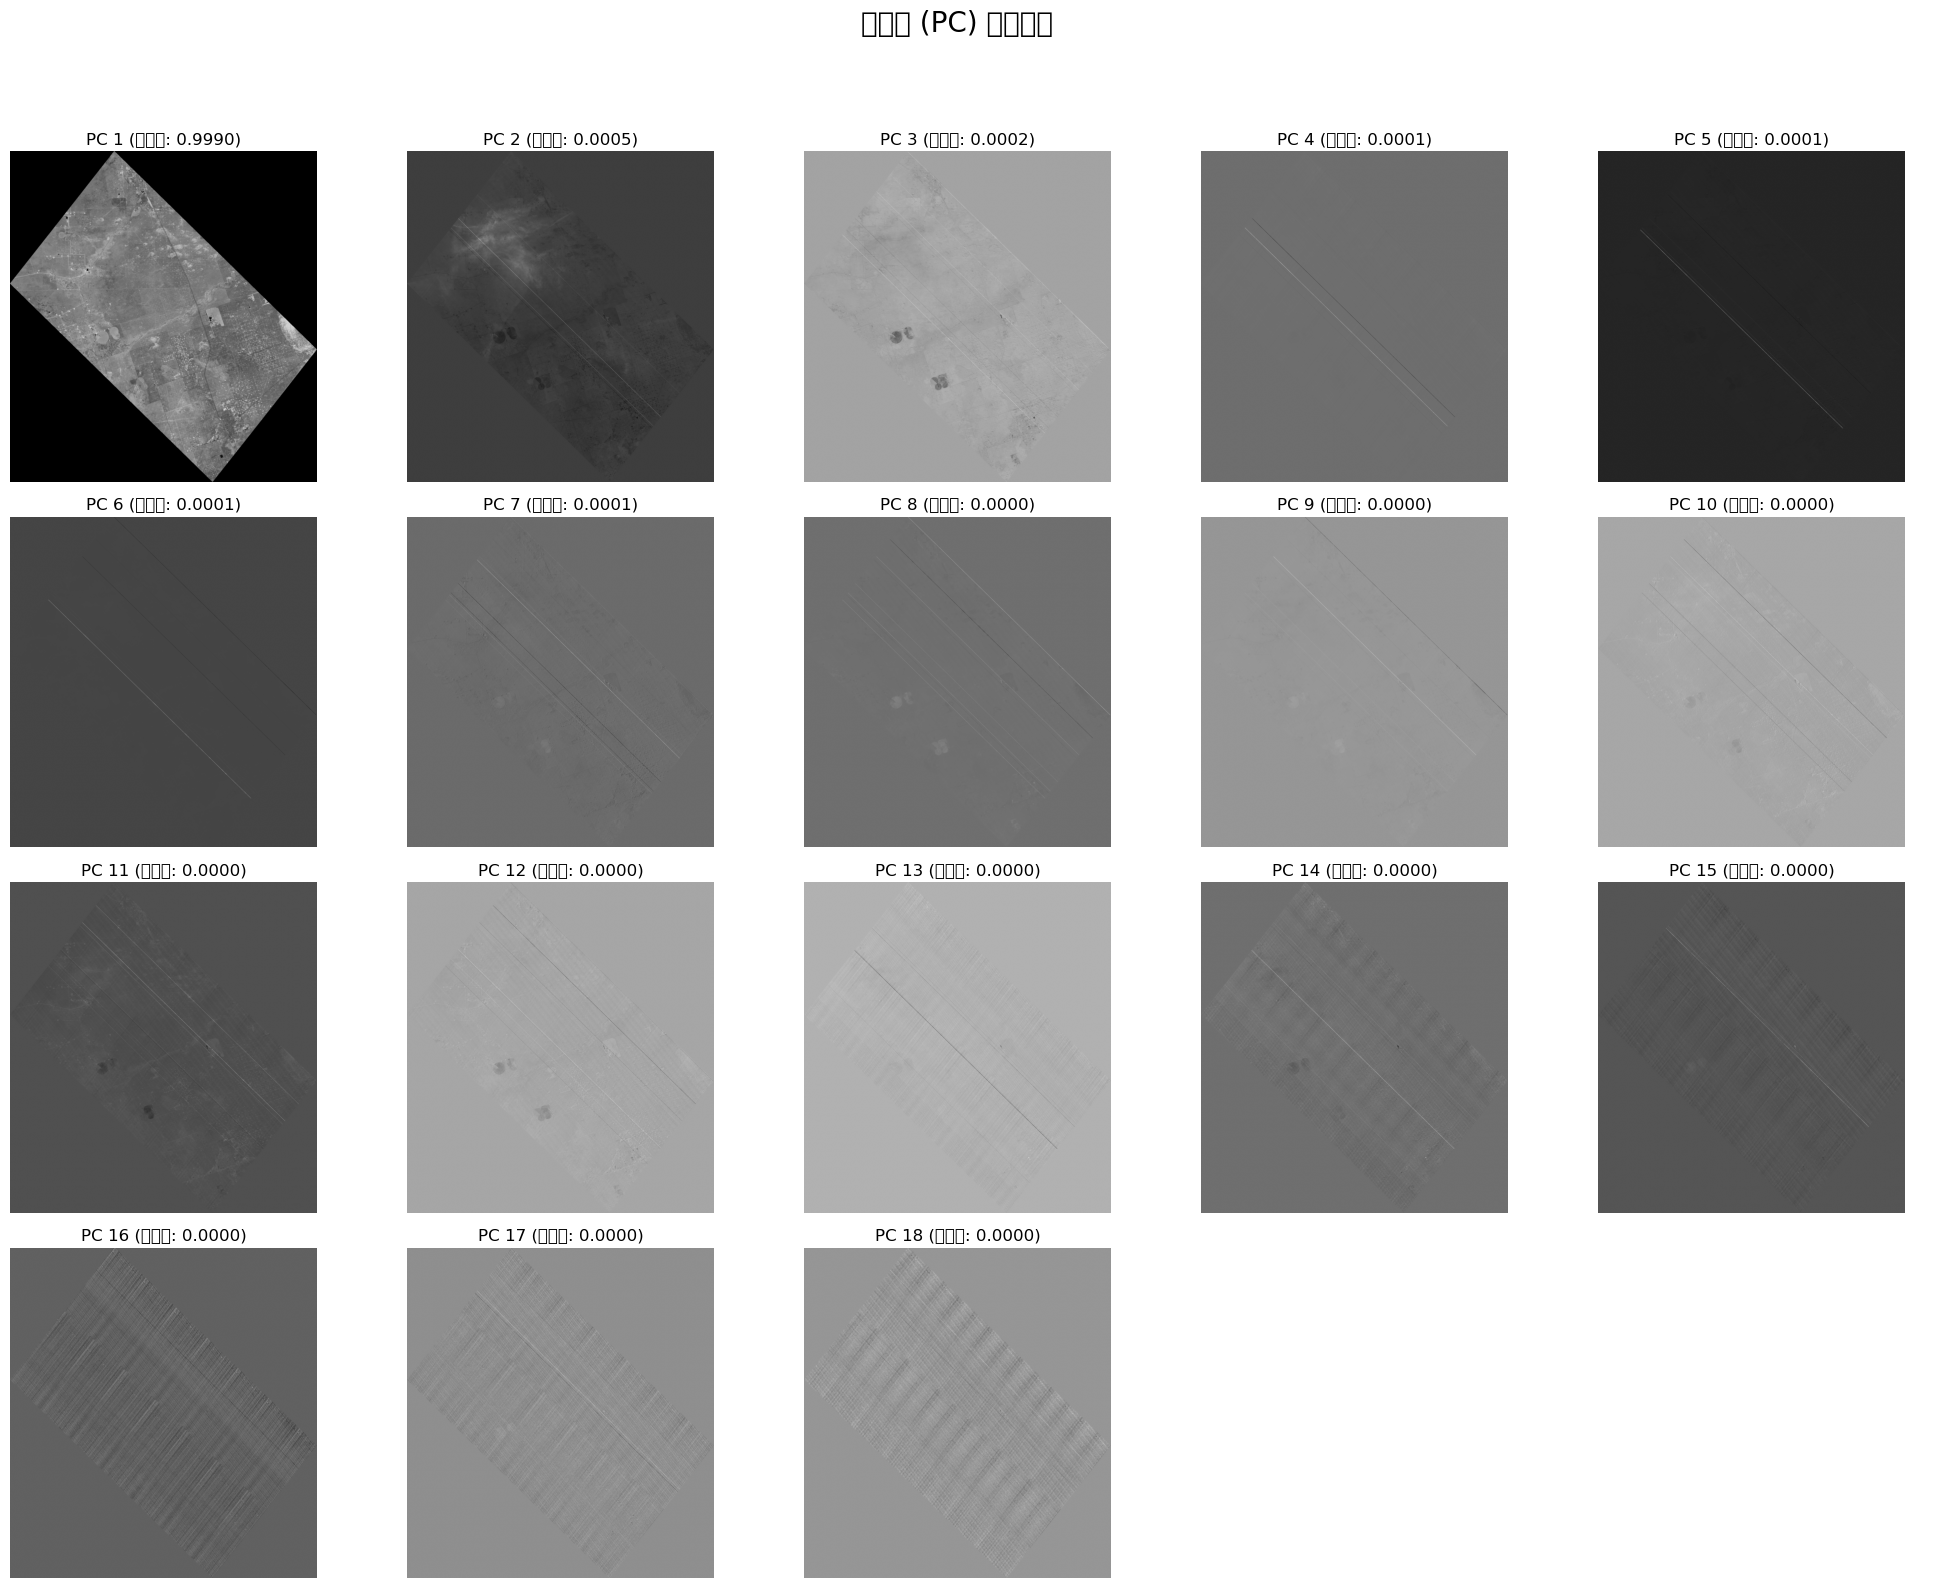


--- 分析 ---
PC1, PC2 (左上) は、地表の様子など「共通の主要な情報」を示します。
PC18 (右下) のような下位の主成分画像に、
「衛星が動く方向に走るエラー」（スジ状のパターン）が現れていないか確認してください。

ステップ6: (オプション) エラーマスクの作成例
仮に、最後の主成分 (PC15) にエラーが映っているとしてマスクを作成します。


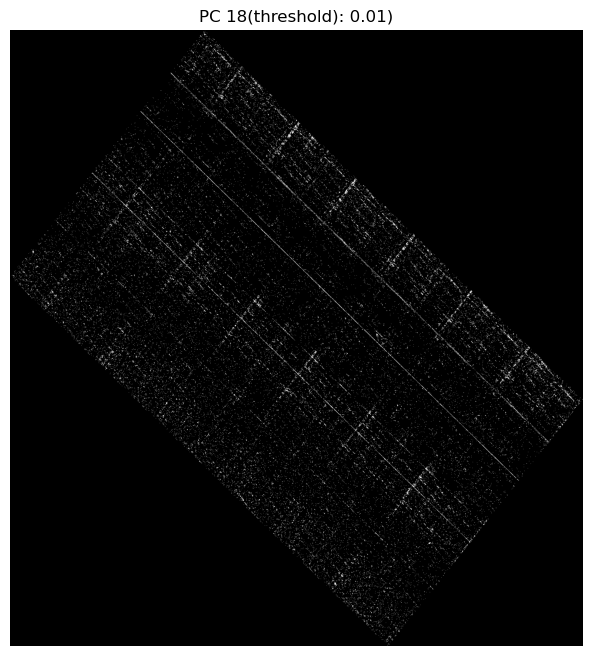

このマスク (True/Falseの配列) を使って、メタン推定時にピクセルを除外できます。


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Matplotlibの日本語設定（オプション：文字化けする場合）
# !pip install japanize-matplotlib
# import japanize_matplotlib

# --- ステップ1: データの読み込みと準備 ---

# 1.1. データの読み込み
# Windowsのパスでは、'\'を'/'に置き換えるか、r"..."を使います
file_path = r"E:\refit\all_map_spectra.csv"
try:
    df = pd.read_csv(file_path)
    print(f"CSVファイルを読み込みました。Shape: {df.shape}")
except FileNotFoundError:
    print(f"エラー: ファイルが見つかりません: {file_path}")
    # このセル以降の実行を停止（Jupyterの場合）
    raise

# 1.2. 使用する波長バンドの定義
start_band = 'wave_1025.91nm'
end_band = 'wave_1238.24nm'

# 1.3. 該当する列（バンド）を抽出
try:
    # 列名から開始インデックスと終了インデックスを取得
    all_columns = df.columns.tolist()
    start_index = all_columns.index(start_band)
    end_index = all_columns.index(end_band)

    # 該当するスペクトルデータを抽出 (X)
    spectral_data = df.iloc[:, start_index : end_index + 1]
    
    # 使用するバンド数を保存
    n_bands_used = spectral_data.shape[1]
    print(f"'{start_band}' から '{end_band}' までの {n_bands_used} バンドを抽出しました。")

except ValueError as e:
    print(f"エラー: 指定されたバンド名が見つかりません。 {e}")
    # このセル以降の実行を停止
    raise

# 1.4. 座標データと画像サイズの取得
# 1列目(y)と2列目(x)を座標として取得
y_coords = df.iloc[:, 0].values.astype(int)
x_coords = df.iloc[:, 1].values.astype(int)

# 座標の最大値から画像サイズを推定 (0始まりと仮定)
H = y_coords.max() + 1
W = x_coords.max() + 1
print(f"推定される画像サイズ: H={H}, W={W}")

# --- ステップ2: データの標準化 ---

print("\nステップ2: データを標準化しています...")
scaler = StandardScaler()
scaled_data = scaler.fit_transform(spectral_data)

# --- ステップ3: PCAの実行と寄与率の確認 ---

print("ステップ3: PCAを実行しています...")
# 全ての主成分を計算 (n_components = 使用バンド数)
pca = PCA(n_components=n_bands_used)
pca_results = pca.fit_transform(scaled_data)

print("PCAが完了しました。")

# 3.2. 寄与率のプロット（スクリープロット）
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_bands_used + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
plt.title('PCA 寄与率 (Scree Plot)', fontsize=16)
plt.xlabel('主成分 (PC)', fontsize=12)
plt.ylabel('寄与率', fontsize=12)
plt.xticks(range(1, n_bands_used + 1))
plt.grid(True)
plt.show()

print(" -> 上位の主成分 (PC1, PC2...) がデータのほとんどを説明し、")
print(" -> 下位の主成分 (PC10, PC11...) の寄与率が低い（＝ノイズやエラー成分）ことを確認してください。")

# --- ステップ4: PCAの結果を画像形式に戻す ---

print("\nステップ4: PCAの結果を (H, W, Components) の画像形式に再構成しています...")

# 結果を格納するための空の3D配列を作成 (NaNで埋める)
pca_image_stack = np.full((H, W, n_bands_used), np.nan)

# y, x座標を使って、PCAの結果（ピクセルごと）を画像配列の正しい位置に挿入
pca_image_stack[y_coords, x_coords] = pca_results

print("画像の再構成が完了しました。")

# --- ステップ5: 主成分画像の可視化（エラーの探索）---

print("\nステップ5: 全ての主成分画像をプロットします...")

# プロットのグリッドサイズを計算 (例: 15バンドなら 3x5)
ncols = 5
nrows = int(np.ceil(n_bands_used / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4))
fig.suptitle('主成分 (PC) の可視化', fontsize=20, y=1.02)

for i in range(n_bands_used):
    if nrows > 1:
        ax = axes.flat[i]
    else:
        ax = axes[i] # 1行の場合

    # 画像データを表示
    # vmin, vmaxでコントラストを調整すると見やすくなる場合があります
    # （例: np.nanpercentile(data, 2), np.nanpercentile(data, 98)）
    img_data = pca_image_stack[:, :, i]
    im = ax.imshow(img_data, cmap='gray')
    
    ax.set_title(f'PC {i+1} (寄与率: {pca.explained_variance_ratio_[i]:.4f})')
    ax.axis('off')
    
# 使わないサブプロットを非表示
for i in range(n_bands_used, len(axes.flat)):
    axes.flat[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

print("\n--- 分析 ---")
print("PC1, PC2 (左上) は、地表の様子など「共通の主要な情報」を示します。")
print(f"PC{n_bands_used} (右下) のような下位の主成分画像に、")
print("「衛星が動く方向に走るエラー」（スジ状のパターン）が現れていないか確認してください。")


# --- ステップ6: (オプション) 異常ピクセルマスクの作成 ---

print("\nステップ6: (オプション) エラーマスクの作成例")
print("仮に、最後の主成分 (PC15) にエラーが映っているとしてマスクを作成します。")

# 例として、最後の主成分画像を使用
# エラーが出ている主成分番号（0から始まるインデックス）に変更してください
noise_component_index = n_bands_used - 1  # 最後の主成分 (例: 15番目ならインデックス14)
noise_image = pca_image_stack[:, :, noise_component_index]

# NaN（データなし領域）を0で埋める（標準偏差の計算のため）
noise_image_filled = np.nan_to_num(noise_image, nan=0.0)

# データの標準偏差を計算
std_dev = np.std(noise_image_filled)

# しきい値（例：平均から±3σ以上離れているピクセルを異常とする）
threshold = std_dev * 3 

# しきい値を超えたピクセルを「異常」(True) とするマスクを作成
# np.abs()で絶対値をとる
error_mask = np.abs(noise_image_filled) > threshold

# マスクの表示
plt.figure(figsize=(8, 8))
plt.imshow(error_mask, cmap='gray')
plt.title(f'PC {noise_component_index + 1}(threshold): {threshold:.2f})')
plt.axis('off')
plt.show()

print("このマスク (True/Falseの配列) を使って、メタン推定時にピクセルを除外できます。")

CSV読み込み: shape=(3335334, 187)
抽出バンド: 'wave_1025.91nm'〜'wave_1238.24nm' の 18 本
推定画像サイズ: H=1894, W=1761

前処理: 1〜99% パーセンタイルでクリップ → 標準化
PCA: svd_solver='full' で全主成分を計算
累積寄与率: 0.9992, 採用PC数 K=1 / 18


C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:116: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:116: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:116: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:116: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:116: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:116: UserWarning: Glyph 29

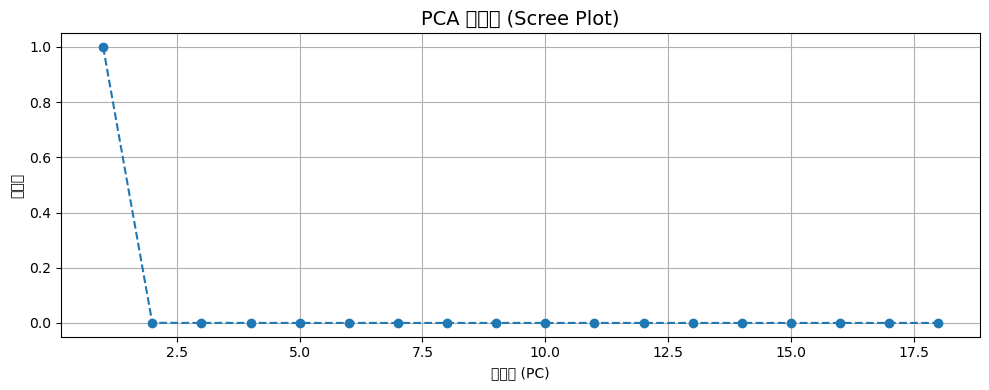

外れ画素（OD/SD, |z|>3.5）: 1562466 / 3335334
ストライプ強調ライン数: 1384（|z|>3.0, PC18使用）


C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:176: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:176: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:176: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:176: UserWarning: Glyph 12494 (\N{KATAKANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3653227342.py:176: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40

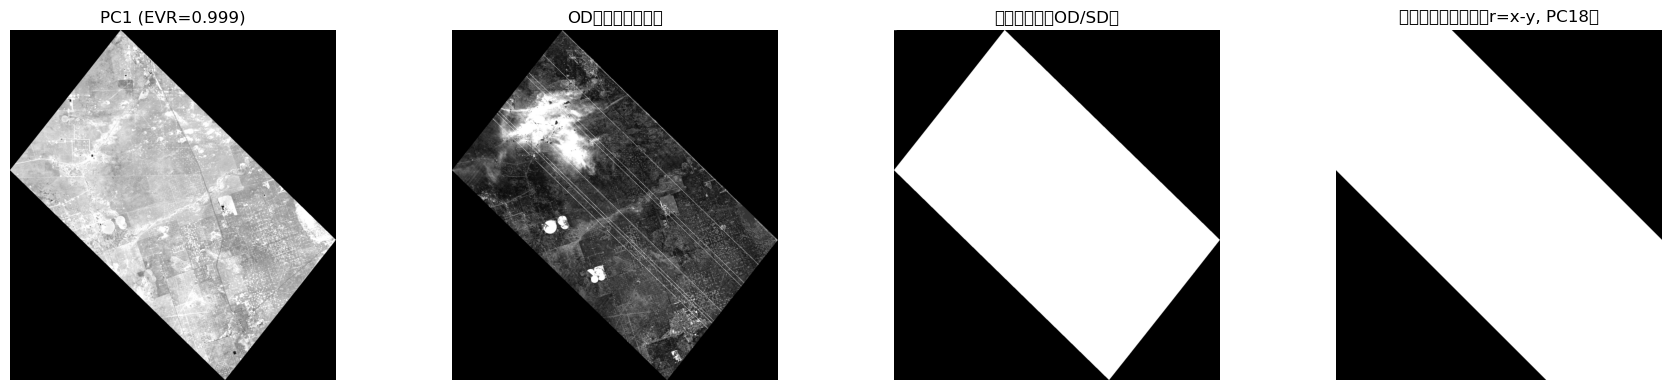

出力: pca_anomaly_mask.npy, pca_stripe_mask.npy, pca_qc_points.csv


In [4]:
# -*- coding: utf-8 -*-
"""
HISUI: PCA による取得不良ピクセル検出（観測方向 = 左上方向（NW）対応版）
 - CSV から (y, x, bands...) を読み込み
 - 指定波長帯のスペクトルに PCA
 - 累積寄与率 99% で K 自動選択
 - OD/SD による外れ画素（ロバスト z）
 - 観測方向（左上 = ( -1, -1 )）に沿うストライプ検出：
   対角指標 r = x - y ごとの PC 値平均にロバスト z を適用
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# ユーザ設定
# ==============================
file_path = r"E:\refit\all_map_spectra.csv"   # 入力CSV
start_band = 'wave_1025.91nm'                 # 使用波長帯（開始）
end_band   = 'wave_1238.24nm'                 # 使用波長帯（終了）
cumexp_target = 0.99                          # 累積寄与率の目標（K自動選択）
z_thresh_outlier = 3.5                        # OD/SD のロバスト z 閾値
z_thresh_stripe  = 3.0                        # ストライプ（対角ライン平均）のロバスト z 閾値
plot_all_pcs = False                          # すべてのPC画像を表示する場合 True
pc_index_for_stripe = -1                      # ストライプ検出に使う PC（-1=最後のPCなど）

# ==============================
# 関数
# ==============================
def robust_z(x):
    """ロバスト z (median/MAD)"""
    x = np.asarray(x)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    mad = mad if mad > 0 else 1e-12
    return (x - med) / (1.4826 * mad)

def show_img(ax, img, title):
    """パーセンタイルストレッチ付き描画"""
    vmin, vmax = np.nanpercentile(img, [2, 98]) if np.isfinite(img).any() else (None, None)
    im = ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    return im

# ==============================
# ステップ1: データ読み込み
# ==============================
try:
    df = pd.read_csv(file_path)
    print(f"CSV読み込み: shape={df.shape}")
except FileNotFoundError:
    raise FileNotFoundError(f"ファイルが見つかりません: {file_path}")

# 列存在チェック
all_columns = df.columns.tolist()
try:
    start_index = all_columns.index(start_band)
    end_index   = all_columns.index(end_band)
except ValueError as e:
    raise ValueError(f"指定バンド名が見つかりません: {e}")

# スペクトルデータ抽出
spectral_data = df.iloc[:, start_index : end_index + 1].copy()
n_bands_used = spectral_data.shape[1]
print(f"抽出バンド: '{start_band}'〜'{end_band}' の {n_bands_used} 本")

# 座標（0-based 整数を想定）
y_coords = df.iloc[:, 0].to_numpy(dtype=int)
x_coords = df.iloc[:, 1].to_numpy(dtype=int)
H = int(y_coords.max()) + 1
W = int(x_coords.max()) + 1
print(f"推定画像サイズ: H={H}, W={W}")

# 欠損・無限大チェック（数値列のみ）
if not np.isfinite(spectral_data.to_numpy()).all():
    print("注意: 欠損/無限大が検出されました。該当行を除外します。")
    valid_rows = np.isfinite(spectral_data.to_numpy()).all(axis=1)
    spectral_data = spectral_data.loc[valid_rows].reset_index(drop=True)
    x_coords = x_coords[valid_rows]
    y_coords = y_coords[valid_rows]

# ==============================
# ステップ2: ロバスト前処理 & 標準化
# ==============================
print("\n前処理: 1〜99% パーセンタイルでクリップ → 標準化")
q1 = spectral_data.quantile(0.01)
q99 = spectral_data.quantile(0.99)
spectral_data = spectral_data.clip(lower=q1, upper=q99, axis=1)

scaler = StandardScaler()
Xz = scaler.fit_transform(spectral_data)   # (N, B)

# ==============================
# ステップ3: PCA（安定志向）
# ==============================
print("PCA: svd_solver='full' で全主成分を計算")
pca = PCA(n_components=n_bands_used, svd_solver='full', random_state=0)
scores = pca.fit_transform(Xz)                 # (N, B)
lambdas = pca.explained_variance_              # (B,)
evr = pca.explained_variance_ratio_
cumexp = np.cumsum(evr)
K = int(np.searchsorted(cumexp, cumexp_target) + 1)
print(f"累積寄与率: {cumexp[K-1]:.4f}, 採用PC数 K={K} / {n_bands_used}")

# スクリープロット
plt.figure(figsize=(10, 4))
plt.plot(range(1, n_bands_used + 1), evr, marker='o', linestyle='--')
plt.title('PCA 寄与率 (Scree Plot)', fontsize=14)
plt.xlabel('主成分 (PC)')
plt.ylabel('寄与率')
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# ステップ4: OD/SD による外れ画素
# ==============================
V = pca.components_                          # (B, B)
Xhat = scores[:, :K] @ V[:K, :]              # (N, B)
OD = np.linalg.norm(Xz - Xhat, axis=1)       # 残差ノルム
SD = np.sqrt((scores[:, :K]**2 / lambdas[:K]).sum(axis=1))

zOD = robust_z(OD)
zSD = robust_z(SD)
anomaly_mask_vec = (np.abs(zOD) > z_thresh_outlier) | (np.abs(zSD) > z_thresh_outlier)

print(f"外れ画素（OD/SD, |z|>{z_thresh_outlier}）: {anomaly_mask_vec.sum()} / {anomaly_mask_vec.size}")

# ==============================
# ステップ5: 画像再構成（必要なもののみ）
# ==============================
pc1_img = np.full((H, W), np.nan); pc1_img[y_coords, x_coords] = scores[:, 0]
OD_img  = np.full((H, W), np.nan); OD_img[y_coords, x_coords]  = OD
anom_img = np.zeros((H, W), dtype=int); anom_img[y_coords, x_coords] = anomaly_mask_vec.astype(int)

# ==============================
# ステップ6: 観測方向（左上）ストライプ検出
# ==============================
"""
観測方向 = 左上（NW）に向かう → ストライプは (1,1) 方向に沿って走ると仮定。
このとき、対角指標 r = x - y が一定のピクセル集合は、(1,1) 方向に平行な線分を形成。
各 r ごとに PC 値の平均を取り、ロバスト z で異常なライン（ストライプ強調）を抽出。
"""
k_idx = pc_index_for_stripe if pc_index_for_stripe >= 0 else (n_bands_used + pc_index_for_stripe)
k_idx = np.clip(k_idx, 0, n_bands_used - 1)

pc_k_img = np.full((H, W), np.nan); pc_k_img[y_coords, x_coords] = scores[:, k_idx]

# 対角指標 r = x - y
r_vals = x_coords - y_coords
df_r = pd.DataFrame({"r": r_vals, "pc": scores[:, k_idx]})
r_means = df_r.groupby("r")["pc"].mean()

z_r = robust_z(r_means.values)
r_unique = r_means.index.to_numpy()
stripe_r_values = r_unique[np.abs(z_r) > z_thresh_stripe]

# ストライプラインに属するピクセルのマスク
stripe_mask_vec = np.isin(r_vals, stripe_r_values)
stripe_mask_img = np.zeros((H, W), dtype=int); stripe_mask_img[y_coords, x_coords] = stripe_mask_vec.astype(int)

print(f"ストライプ強調ライン数: {len(stripe_r_values)}（|z|>{z_thresh_stripe}, PC{ k_idx+1 }使用）")

# ==============================
# ステップ7: 可視化
# ==============================
fig, axs = plt.subplots(1, 4, figsize=(18, 4))
show_img(axs[0], pc1_img, f"PC1 (EVR={evr[0]:.3f})")
show_img(axs[1], OD_img, "OD（残差ノルム）")
axs[2].imshow(anom_img, cmap='gray'); axs[2].set_title("異常マスク（OD/SD）"); axs[2].axis('off')
axs[3].imshow(stripe_mask_img, cmap='gray'); axs[3].set_title(f"ストライプマスク（r=x-y, PC{ k_idx+1 }）"); axs[3].axis('off')
plt.tight_layout(); plt.show()

# すべてのPC表示（必要時）
if plot_all_pcs:
    ncols = 5
    nrows = int(np.ceil(n_bands_used / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 3.6, nrows * 3.6))
    fig.suptitle('主成分 (PC) の可視化', fontsize=16, y=1.02)
    for i in range(n_bands_used):
        ax = axes.flat[i] if nrows > 1 else axes[i]
        pc_img = np.full((H, W), np.nan); pc_img[y_coords, x_coords] = scores[:, i]
        show_img(ax, pc_img, f'PC {i+1} (EVR={evr[i]:.4f})')
    for j in range(n_bands_used, len(axes.flat)):
        axes.flat[j].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()

# ==============================
# ステップ8: 保存（任意）
# ==============================
np.save("pca_anomaly_mask.npy", anom_img.astype(bool))
np.save("pca_stripe_mask.npy", stripe_mask_img.astype(bool))
pd.DataFrame({
    "y": y_coords, "x": x_coords,
    "OD": OD, "SD": SD,
    "zOD": zOD, "zSD": zSD,
    "anomaly": anomaly_mask_vec.astype(int),
    "stripe": stripe_mask_vec.astype(int),
    "r": r_vals
}).to_csv("pca_qc_points.csv", index=False)

print("出力: pca_anomaly_mask.npy, pca_stripe_mask.npy, pca_qc_points.csv")


読み込み: E:\refit\all_map_spectra.csv  shape=(3335334, 187)
画像サイズ推定: H=1894, W=1761, バンド=18
PCA: K=1（累積寄与率=0.9992）


C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:135: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.xlabel('主成分'); plt.ylabel('寄与率'); plt.grid(True); plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:135: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.xlabel('主成分'); plt.ylabel('寄与率'); plt.grid(True); plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:135: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.xlabel('主成分'); plt.ylabel('寄与率'); plt.grid(True); plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:135: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  plt.xlabel('主成分'); plt.ylabel('寄与率'); plt.grid(True); plt.tight_layout()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\334788

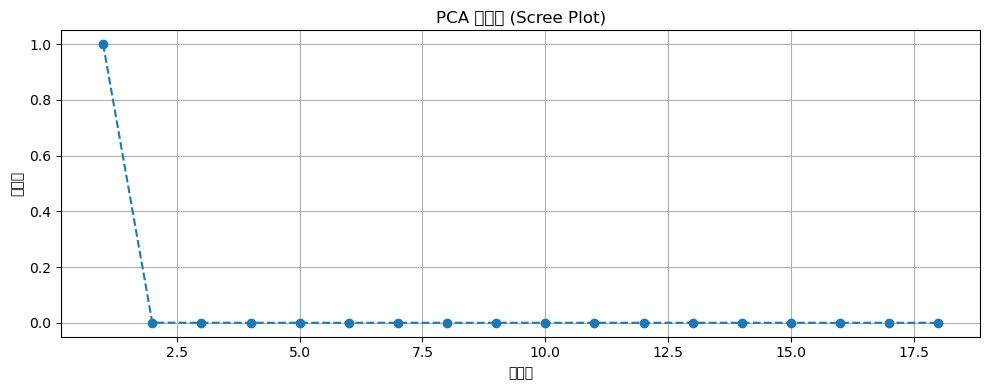

外れ画素（OD/SD）: 1562466 / 3335334
Hough 検出ライン数（ピーク数）: 2


C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:216: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:216: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:216: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:216: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\Temp\ipykernel_40600\3347885351.py:216: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yudon\AppData\Local\

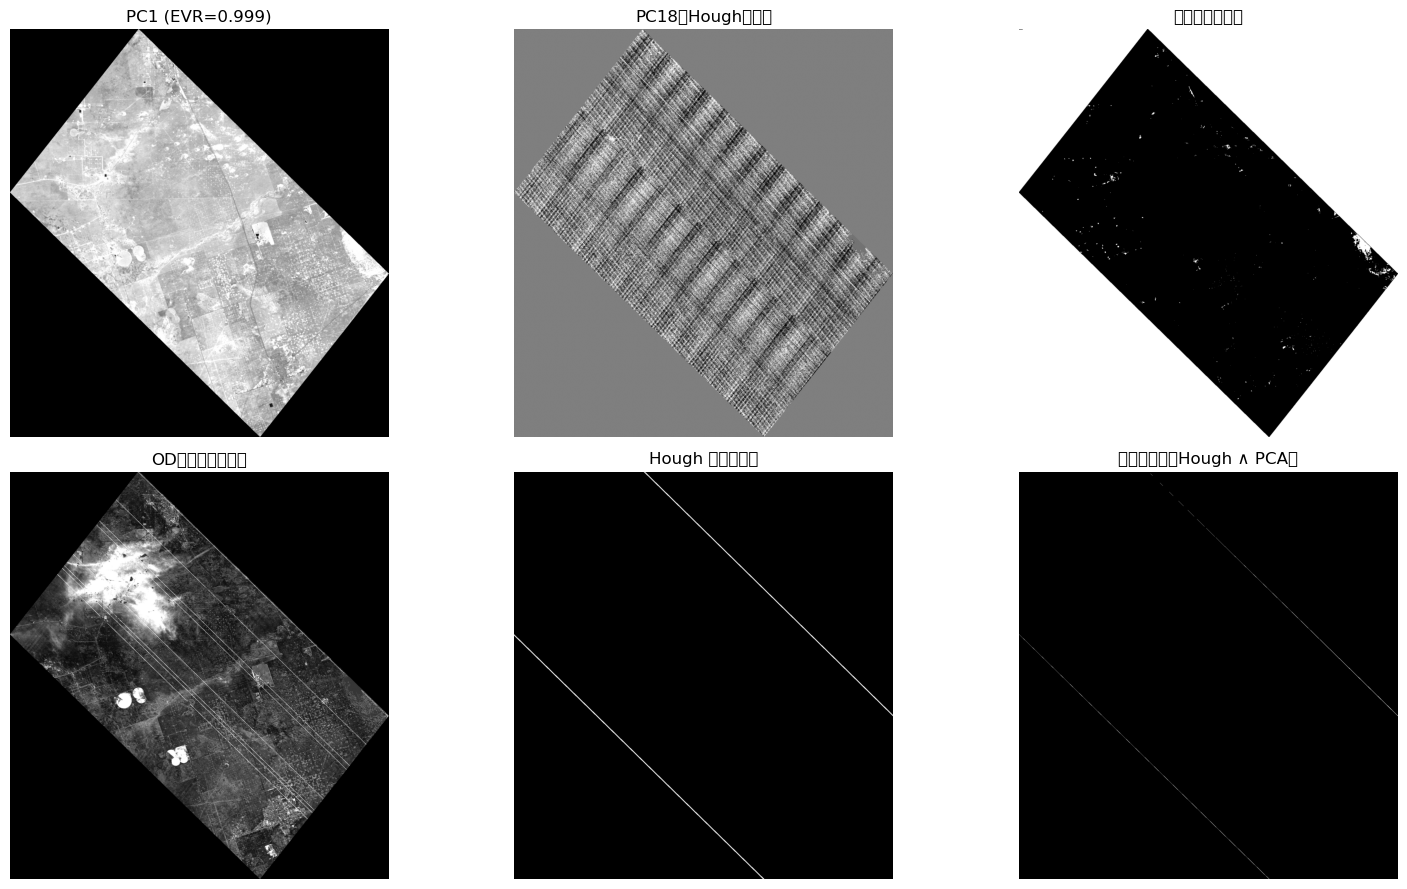

出力: pca_anomaly_mask.npy, hough_stripe_mask.npy, final_mask_pca_and_hough.npy, qc_points_pca_hough.csv


In [6]:
# -*- coding: utf-8 -*-
"""
HISUI: PCA + Hough によるストライプ/異常ピクセル検出
 - 入力CSV: E:\refit\all_map_spectra.csv
 - 使用波長帯: wave_1025.91nm 〜 wave_1238.24nm
 - 観測方向は左上（NW） → (1,1) 方向の直線（法線角 ≈ 135°）のみ検出
 - 出力: PCA異常マスク, Houghストライプマスク, 最終マスク（AND）
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.ndimage import gaussian_filter, binary_dilation
from skimage.feature import canny
from skimage.transform import hough_line, hough_line_peaks

# ==============================
# ユーザ設定
# ==============================
file_path = r"E:\refit\all_map_spectra.csv"  # 入力CSV
start_band = 'wave_1025.91nm'                # 使用波長帯（開始）
end_band   = 'wave_1238.24nm'                # 使用波長帯（終了）

# PCA 設定
cumexp_target       = 0.99   # 累積寄与率でK自動選択
z_thresh_outlier    = 3.5    # OD/SDのロバストz閾値

# 均質領域ゲート（PC1勾配が小さい領域だけでライン統計/投票）
homog_grad_percentile = 40.0  # 下位％のみ採用（小さいほど厳しい）

# Hough（(1,1) 方向=法線135° 周辺のみ）
theta_center_deg    = 135.0   # 法線角（度）
dtheta_deg          = 4.0     # 許容角（±）
num_thetas          = 121     # 評価する角度数
hough_num_peaks     = 64      # 取り出すピーク数
hough_thr_ratio     = 0.40    # 閾値: 最大値の何倍か
line_width_px       = 3.0     # 直線を帯化する幅（画素）
dilate_iterations   = 1       # マスク後処理（膨張）の回数

# Canny エッジ
canny_sigma         = 1.2
canny_low_thr       = 0.10
canny_high_thr      = 0.30

# ストライプ検出に使うPC（-1=最後, -2=最後から2番目）
pc_index_for_hough  = -1

# 可視化
plot_all_pcs        = False

# ==============================
# ユーティリティ
# ==============================
def robust_z(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad <= 0:
        mad = 1e-12
    return (x - med) / (1.4826 * mad)

def show_img(ax, img, title):
    if np.isfinite(img).any():
        vmin, vmax = np.nanpercentile(img, [2, 98])
    else:
        vmin = vmax = None
    im = ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    return im

# ==============================
# 1) データ読み込み・抽出
# ==============================
try:
    df = pd.read_csv(file_path)
    print(f"読み込み: {file_path}  shape={df.shape}")
except FileNotFoundError:
    raise FileNotFoundError(f"ファイルが見つかりません: {file_path}")

cols = df.columns.tolist()
try:
    si = cols.index(start_band)
    ei = cols.index(end_band)
except ValueError as e:
    raise ValueError(f"指定バンドが見つかりません: {e}")

spectral = df.iloc[:, si:ei+1].copy()
n_bands  = spectral.shape[1]
y_coords = df.iloc[:, 0].to_numpy(int)
x_coords = df.iloc[:, 1].to_numpy(int)
H = y_coords.max() + 1
W = x_coords.max() + 1
print(f"画像サイズ推定: H={H}, W={W}, バンド={n_bands}")

# 欠損/無限大の行は除外
if not np.isfinite(spectral.to_numpy()).all():
    valid = np.isfinite(spectral.to_numpy()).all(axis=1)
    dropped = (~valid).sum()
    print(f"NaN/Inf 行を除外: {dropped} 行")
    spectral = spectral.loc[valid].reset_index(drop=True)
    y_coords = y_coords[valid]
    x_coords = x_coords[valid]

# ==============================
# 2) ロバスト前処理 → 標準化
# ==============================
q1, q99 = spectral.quantile(0.01), spectral.quantile(0.99)
spectral = spectral.clip(lower=q1, upper=q99, axis=1)

scaler = StandardScaler()
Xz = scaler.fit_transform(spectral)   # (N, B)
N = Xz.shape[0]

# ==============================
# 3) PCA 本体
# ==============================
pca = PCA(n_components=n_bands, svd_solver='full', random_state=0)
scores = pca.fit_transform(Xz)   # (N, B)
lambdas = pca.explained_variance_
evr = pca.explained_variance_ratio_
cumexp = np.cumsum(evr)
K = int(np.searchsorted(cumexp, cumexp_target) + 1)
print(f"PCA: K={K}（累積寄与率={cumexp[K-1]:.4f}）")

# スクリープロット
plt.figure(figsize=(10,4))
plt.plot(range(1, n_bands+1), evr, marker='o', linestyle='--')
plt.title('PCA 寄与率 (Scree Plot)')
plt.xlabel('主成分'); plt.ylabel('寄与率'); plt.grid(True); plt.tight_layout()
plt.show()

# ==============================
# 4) 外れ画素（OD/SD）＋ロバストz
# ==============================
V = pca.components_               # (B, B)
Xhat = scores[:, :K] @ V[:K, :]   # (N, B)
OD = np.linalg.norm(Xz - Xhat, axis=1)
SD = np.sqrt((scores[:, :K]**2 / lambdas[:K]).sum(axis=1))
zOD, zSD = robust_z(OD), robust_z(SD)
pix_anom_vec = (np.abs(zOD) > z_thresh_outlier) | (np.abs(zSD) > z_thresh_outlier)
print(f"外れ画素（OD/SD）: {pix_anom_vec.sum()} / {N}")

# 画像配置
pc1_img = np.full((H, W), np.nan); pc1_img[y_coords, x_coords] = scores[:, 0]
OD_img  = np.full((H, W), np.nan); OD_img [y_coords, x_coords] = OD
anom_img= np.zeros((H, W), dtype=int); anom_img[y_coords, x_coords] = pix_anom_vec.astype(int)

# ==============================
# 5) Hough: (1,1) 方向の直線だけ検出
# ==============================
# 5.1 ストライプ検出に使うPC画像（デフォルトは最後のPC）
k = pc_index_for_hough if pc_index_for_hough >= 0 else (n_bands + pc_index_for_hough)
k = int(np.clip(k, 0, n_bands-1))
pc_k_img = np.full((H, W), np.nan); pc_k_img[y_coords, x_coords] = scores[:, k]

# 5.2 均質領域（PC1勾配が小さい領域のみ採用）で偽陽性抑制
pc1_for_grad = np.nan_to_num(pc1_img, nan=np.nanmedian(pc1_img))
gy, gx = np.gradient(pc1_for_grad)
gmag = np.sqrt(gx**2 + gy**2)
g_thr = np.nanpercentile(gmag, homog_grad_percentile)
homog_mask = (gmag <= g_thr) & np.isfinite(pc_k_img)

# 5.3 前処理 → Canny
im = np.nan_to_num(pc_k_img, nan=np.nanmedian(pc_k_img))
im = gaussian_filter(im, sigma=1.0)
p2, p98 = np.percentile(im, [2, 98])
im_norm = np.clip((im - p2) / max(p98 - p2, 1e-6), 0, 1)

edges = canny(im_norm, sigma=canny_sigma, low_threshold=canny_low_thr, high_threshold=canny_high_thr)
edges &= homog_mask

# 5.4 角度制限付き Hough（法線角 135°±dθ）
thetas = np.deg2rad(np.linspace(theta_center_deg - dtheta_deg, theta_center_deg + dtheta_deg, num_thetas))
Hspace, ths, rhos = hough_line(edges, theta=thetas)

thr = hough_thr_ratio * (Hspace.max() if Hspace.size else 0.0)
accums, angles, dpeaks = hough_line_peaks(Hspace, ths, rhos,
                                          num_peaks=hough_num_peaks,
                                          threshold=thr)

# 5.5 ピークから帯マスク作成
Y, X = np.mgrid[0:H, 0:W]
hough_mask = np.zeros((H, W), dtype=bool)
for th, rho in zip(angles, dpeaks):
    dist = np.abs(X * np.cos(th) + Y * np.sin(th) - rho)
    hough_mask |= dist <= (line_width_px / 2.0)

if dilate_iterations > 0:
    hough_mask = binary_dilation(hough_mask, iterations=dilate_iterations)

print(f"Hough 検出ライン数（ピーク数）: {len(dpeaks)}")

# ==============================
# 6) 最終マスク（AND合成 = Hough ∧ PCA外れ）
# ==============================
final_mask = hough_mask & anom_img.astype(bool)

# ==============================
# 7) 可視化
# ==============================
fig, axs = plt.subplots(2, 3, figsize=(16, 9))
show_img(axs[0,0], pc1_img, f"PC1 (EVR={evr[0]:.3f})")
show_img(axs[0,1], pc_k_img, f"PC{k+1}（Hough入力）")
axs[0,2].imshow(homog_mask, cmap='gray'); axs[0,2].set_title("均質領域マスク"); axs[0,2].axis('off')

show_img(axs[1,0], OD_img, "OD（残差ノルム）")
axs[1,1].imshow(hough_mask, cmap='gray'); axs[1,1].set_title("Hough ストライプ"); axs[1,1].axis('off')
axs[1,2].imshow(final_mask, cmap='gray'); axs[1,2].set_title("最終マスク（Hough ∧ PCA）"); axs[1,2].axis('off')

plt.tight_layout(); plt.show()

# 任意：すべてのPC表示
if plot_all_pcs:
    ncols = 5
    nrows = int(np.ceil(n_bands / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3.4, nrows*3.4))
    fig.suptitle('主成分 (PC) 可視化', fontsize=16, y=1.02)
    for i in range(n_bands):
        ax = axes.flat[i] if nrows > 1 else axes[i]
        pc_img = np.full((H, W), np.nan); pc_img[y_coords, x_coords] = scores[:, i]
        show_img(ax, pc_img, f'PC {i+1} (EVR={evr[i]:.3f})')
    for j in range(n_bands, len(axes.flat)):
        axes.flat[j].axis('off')
    plt.tight_layout(rect=[0,0.03,1,0.98]); plt.show()

# ==============================
# 8) 保存
# ==============================
np.save("pca_anomaly_mask.npy", anom_img.astype(bool))
np.save("hough_stripe_mask.npy", hough_mask.astype(bool))
np.save("final_mask_pca_and_hough.npy", final_mask.astype(bool))

pd.DataFrame({
    "y": y_coords, "x": x_coords,
    "OD": OD, "SD": SD,
    "zOD": zOD, "zSD": zSD,
    "pca_anom": (pix_anom_vec.astype(int)),
    "hough":    (hough_mask[y_coords, x_coords].astype(int)),
    "final":    (final_mask[y_coords, x_coords].astype(int))
}).to_csv("qc_points_pca_hough.csv", index=False)

print("出力: pca_anomaly_mask.npy, hough_stripe_mask.npy, final_mask_pca_and_hough.npy, qc_points_pca_hough.csv")
